Reference Molecule:


[15:48:16] Initializing Normalizer


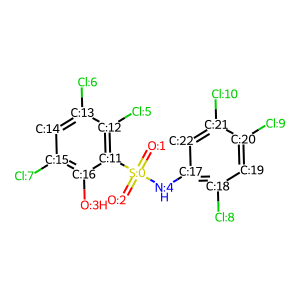

Fixed Fragment:


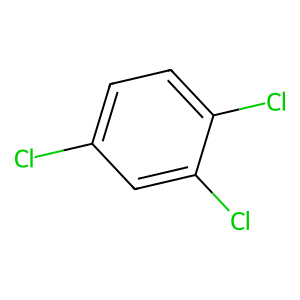

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [1]:
import py3Dmol
from rdkit import Chem
from rdkit.Chem import Draw

from src.mlconfgen.utils import get_context_shape
from src.mlconfgen.cheminformatics.pipeline import set_conformer_positions

import torch

def new_mol_from_atom_indices(mol: Chem.Mol, atom_indices) -> Chem.Mol:
    
    keep = sorted(set(int(i) for i in atom_indices))
    
    n = mol.GetNumAtoms()
    if keep[0] < 0 or keep[-1] > n:
        raise IndexError(f"atom index out of range (0..{n-1}): {keep}")

    keep_set = set(keep)

    # Map old atom idx -> new atom idx
    rw = Chem.RWMol()
    old2new = {}
    for old_i in keep:
        # Copy the atom object to preserve charge/isotope/aromaticity/etc.
        new_i = rw.AddAtom(Chem.Atom(mol.GetAtomWithIdx(old_i)))
        old2new[old_i] = new_i

    # Add bonds that connect kept atoms
    for b in mol.GetBonds():
        a, c = b.GetBeginAtomIdx(), b.GetEndAtomIdx()
        if a in keep_set and c in keep_set:
            rw.AddBond(old2new[a], old2new[c], b.GetBondType())
            nb = rw.GetBondBetweenAtoms(old2new[a], old2new[c])
            nb.SetIsAromatic(b.GetIsAromatic())

    out = rw.GetMol()

    # Copy coordinates for EACH conformer
    out.RemoveAllConformers()
    for conf in mol.GetConformers():
        new_conf = Chem.Conformer(len(keep))
        new_conf.Set3D(conf.Is3D())
        for old_i in keep:
            new_conf.SetAtomPosition(old2new[old_i], conf.GetAtomPosition(old_i))
        out.AddConformer(new_conf, assignId=True)

    return out

CONTEXT_NORMS = {
    'mean': torch.tensor([92.1179, 413.7875, 470.5253]),
    'mad': torch.tensor([53.4742, 232.5775, 251.1813]),
}

# Load a Reference conformer
ref_mol = Chem.MolFromMolFile('./assets/demo_files/yibfeu.mol')
# Load a Fragment, which you want generated molecules would have
# fixed_fragment = Chem.MolFromMolFile('./assets/demo_files/frag_yibfeu.mol')

# Align molecule First
ref_coord = torch.tensor(ref_mol.GetConformer().GetPositions())

# Introduce a shift
ref_coord = ref_coord + torch.tensor([5, 2, 1])

# Create a Mol object from shifted coord
ref_mol_world = set_conformer_positions(ref_mol, ref_coord)

# Extrac Fragment from shifted "World Coord"
fixed_fragment_world = new_mol_from_atom_indices(ref_mol_world,
                                            [8, 9, 10, 17, 18, 19, 20, 21, 22])


# Put ref_mol_world into principal frame
virtual_com = torch.mean(ref_coord, dim=0)
ref_coord = ref_coord - virtual_com
ref_context, aligned_coord, rotation = get_context_shape(ref_coord, include_rotation=True)
ref_mol = set_conformer_positions(ref_mol, aligned_coord)

# Get FF coordinates and appy the same transform

ff_coord = torch.tensor(fixed_fragment_world.GetConformer().GetPositions())
ff_coord = ff_coord - virtual_com
ff_coord_aligned = torch.matmul(ff_coord.to(torch.float32), rotation)
fixed_fragment = set_conformer_positions(fixed_fragment_world, ff_coord_aligned)

print("Reference Molecule:")
for a in ref_mol.GetAtoms():
        a.SetProp("molAtomMapNumber", str(a.GetIdx()))
    
display(Draw.MolToImage(Chem.MolFromSmiles(Chem.MolToSmiles(ref_mol)), includeAtomNumbers=True))

print("Fixed Fragment:")

display(Draw.MolToImage(Chem.MolFromSmiles(Chem.MolToSmiles(fixed_fragment))))

ref_block = Chem.MolToXYZBlock(ref_mol)
frag_block = Chem.MolToXYZBlock(fixed_fragment)


ref_block = Chem.MolToMolFile(ref_mol, "ff_yibfeu.mol")
frag_block = Chem.MolToMolFile(fixed_fragment, "ff_yibfeu_fragment.mol")

view = py3Dmol.view()
view.addModel(ref_block, "xyz")
view.setStyle(
            {"model": 0},
            {"stick": {"color": "magenta", "radius": 0.05}},
        )

view.addModel(frag_block, "xyz")


view.setStyle(
                {"model":1},
                {"stick": {"radius": 0.2}},
            )

view.show()